---
categories:
- PPEC
- Ensino
- Estatística
date: 2023-03-16
description: Aula 6 - Notebook sobre Regressão Linear e Correlação
image: Aula_de_Regressão_Linear_e_Correlação.png
title: "Regressão Linear e Correlação"
---

<a href="https://colab.research.google.com/github/Ludmilla-Borges/PPEC0039/blob/main/Aula_de_Regress%C3%A3o_Linear_e_Correla%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

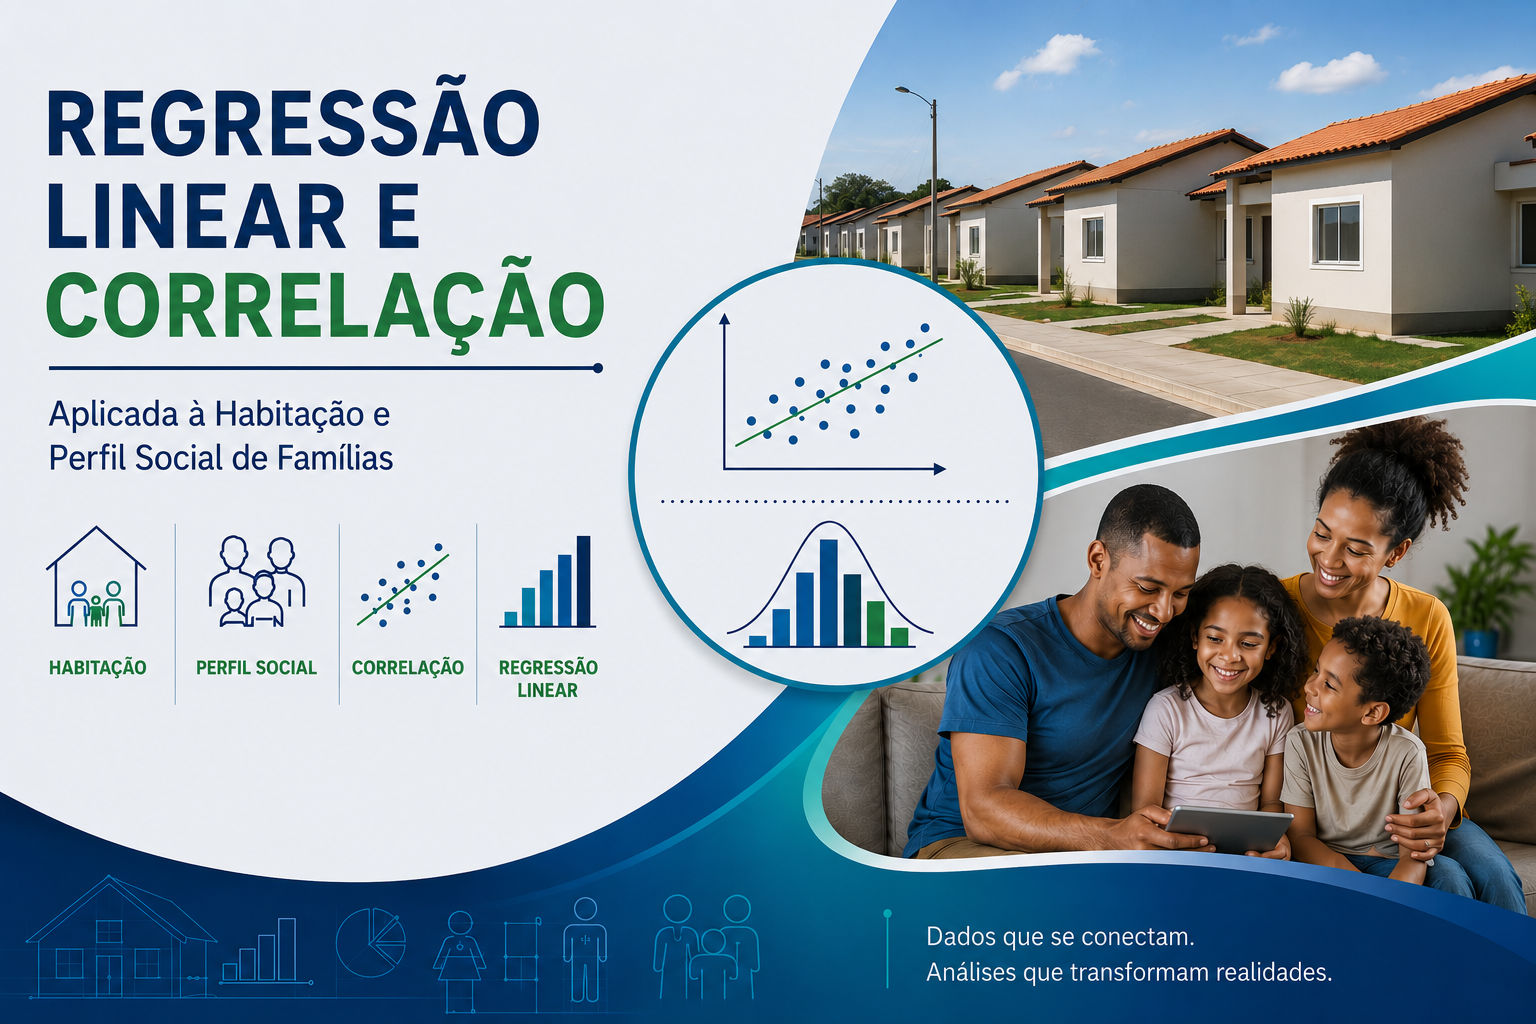

# **Aula de Regressão Linear e Correlação**

Essa aula irá abordar os conceitos e exemplos de regressão linear e correlação que fazem parte da estatística aplicada à pesquisa.

Os exemplos aqui apresentados irão abordar estudos voltados à implantação de projetos de saneamento básico e habitação.

## **1.Regressão Linear**

Primeiramente, vamos partir do **conceito central** da estatística sobre a regressão linear:

A regressão linear é um instrumento estatístico para resumir dados e informações.

É um dos métodos estatísticos mais utilizados para analisar relações entre variáveis e fazer previsões.

Ao analisar uma regressão, a preocupação será sempre com a **dependência** estatística entre as **variaveis**.

As relações de uma regressão linear são entre **variáveis dependentes** e **variáveis independentes**.

É através da relação das variáveis, que a regressão linear tenta encontrar uma **linha reta** que melhor represente as **relações** dessas variáveis.

Os objetivos da regressão linear são:



*   Explicar relações
*   Fazer Previsões
*   Quantificar impactos

Para compor a regressão linear, se utiliza os seguintes dados:

*  y → valor previsto da variável dependente
*  a → intercepto da reta (onde a linha cruza o eixo Y)
*  b → coeficiente angular/inclinação da reta
*  x → variável independente

Enquanto ao comportamento do modelo linear, ele pode ser:

*  Positivo

Conforme **x** aumenta, **y** também tende a aumentar

*  Negativa

Conforme **x** aumenta, **y** diminui.

*  Nula ou Fraca

Não existe uma tendência linear, o coeficiente angular (**b**) é próximo de zero.

*  Não Linear

A relação de **x** e **y** forma uma curva, parábola, exponencial, logarítmica ou sigmoide.

Os dois principais tipos de regressão linear são: **Regressão Linear Simples** e **Regressão Linear Múltipla**.

Na regressão linear simples, se utiliza apenas uma váriavel dependente e uma variável independente. Já na Linear Múltipla, são varias variáveis independentes e uma variável dependente.

Os dados que podem ser utilizados são:

*  Contínuos
*  Discretos (Se forem contagens pequenas ou distribuições assimétricas, outros modelos são melhores)
*  Percentuais e Taxas

### **Exemplo:**

Foi aplicado um questionário em uma área Municipal para identificar défict habitacional e a partir desses dados, foi realizado uma regressão linear para identificar a relação linear entre a renda média da família e a demanda habitacional.
Os dados apresentados nesse exemplos serão simulados de forma aleatória, contudo, poderiam ser utilizados a partir de uma planilha de cadastro real ou simulado.

Para realizar todas essas etapas, utilizaremos as seguintes bibliotecas:

*  Pandas (pandas) — leitura, organização e manipulação de dados tabulares;
*  NumPy (numpy) — operações numéricas e geração de dados simulados;
*  biblioteca math — realização de operações matemáticas;
*  Matplotlib (matplotlib) — criação de gráficos e visualização dos dados;
*  SciPy (scipy.stats) — aplicação de métodos estatísticos;
*  scikit-learn (sklearn) — construção e aplicação do modelo de regressão linear.

Primeiras linhas da tabela:
   renda_media  deficit_habitacional
0  2747.608618            338.625366
1  5743.714393            143.416842
2  4606.368497            227.288321
3  3913.024118            185.715796
4  1611.296930            394.535309

Estatística descritiva:
       renda_media  deficit_habitacional
count   100.000000            100.000000
mean   3244.939866            305.260394
std    1546.944937            104.709423
min     828.715009             73.971957
25%    1804.643956            213.046271
50%    3213.540764            302.072369
75%    4597.056220            399.643313
max    5931.812070            520.055985


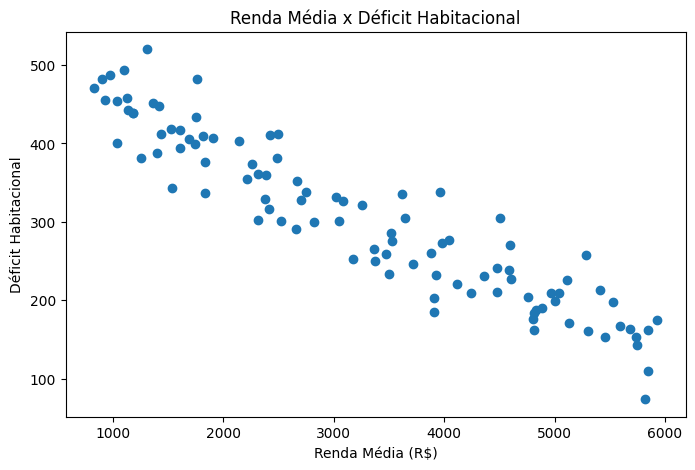


Resultados da Regressão Linear
Intercepto (a): 511.4332
Coeficiente angular (b): -0.0635

Equação da reta:
y = 511.43 + (-0.0635 * x)

Coeficiente de determinação (R²): 0.8811

Interpretação:
Existe uma relação linear negativa entre renda média e déficit habitacional.
Aproximadamente 88.11% da variação do déficit habitacional é explicada pela renda média.


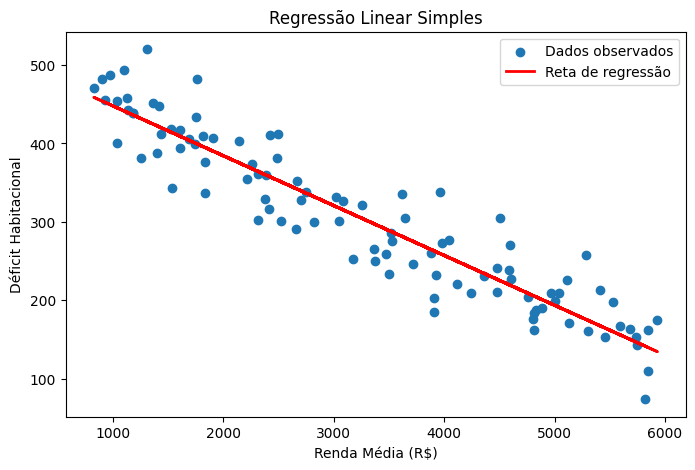


Conclusão:
Os dados simulados indicam que quanto maior a renda média, menor é a necessidade por uma unidade habitacional, demonstrando uma relação linear negativa entre as variáveis.


In [ ]:
# IMPORTAÇÃO DAS BIBLIOTECAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# Garante reprodutibilidade dos dados aleatórios
np.random.seed(42)

# Criação dos dados

# Quantidade de observações
n = 100

# Simulando renda média (R$)
renda_media = np.random.uniform(800, 6000, n)

# Criando relação linear
# Quanto maior a renda, menor o déficit habitacional
# O 0.06 é um coeficiente angular simulado.

deficit_habitacional = 500 - (0.06 * renda_media)

# Adicionando ruído aleatório para deixar os dados mais realistas
ruido = np.random.normal(0, 40, n)

deficit_habitacional = deficit_habitacional + ruido

# Criando o gráfico


df = pd.DataFrame({
    'renda_media': renda_media,
    'deficit_habitacional': deficit_habitacional
})

# Exibindo os primeiros registros simulados
print("Primeiras linhas da tabela:")
print(df.head())



# Exibindo a estatítica dos dados

print("\nEstatística descritiva:")
print(df.describe())



# Gráfico de dispersão

plt.figure(figsize=(8,5))

plt.scatter(
    df['renda_media'],
    df['deficit_habitacional']
)

plt.xlabel('Renda Média (R$)')
plt.ylabel('Déficit Habitacional')
plt.title('Renda Média x Déficit Habitacional')

plt.show()



# Regressão Linear

# Variável independente (X)
X_renda = df[['renda_media']]

# Variável dependente (Y)
y_deficithab = df['deficit_habitacional']

# Criando modelo
modelo = LinearRegression()

# Treinando modelo
modelo.fit(X_renda, y_deficithab)

# Gerando previsões
y_deficithab_pred = modelo.predict(X_renda)


# Resultados

print("\nResultados da Regressão Linear")

# Intercepto
print(f"Intercepto (a): {modelo.intercept_:.4f}")

# Coeficiente angular
print(f"Coeficiente angular (b): {modelo.coef_[0]:.4f}")

# Equação da reta
print(
    f"\nEquação da reta:\n"
    f"y = {modelo.intercept_:.2f} + "
    f"({modelo.coef_[0]:.4f} * x)"
)

# Coeficiente de determinação
r2 = r2_score(y_deficithab, y_deficithab_pred)

print(f"\nCoeficiente de determinação (R²): {r2:.4f}")


# Interpretação

print("\nInterpretação:")

if modelo.coef_[0] < 0:
    print(
        "Existe uma relação linear negativa entre "
        "renda média e déficit habitacional."
    )
else:
    print(
        "Existe uma relação linear positiva entre "
        "renda média e déficit habitacional."
    )

print(
    f"Aproximadamente {r2*100:.2f}% da variação "
    f"do déficit habitacional é explicada pela renda média."
)


# Gráfico com linha de regressão

plt.figure(figsize=(8,5))

# Dados observados
plt.scatter(
    df['renda_media'],
    df['deficit_habitacional'],
    label='Dados observados'
)

# Linha de regressão
plt.plot(
    df['renda_media'],
    y_deficithab_pred,
    linewidth=2,
    color='red',
    label='Reta de regressão'
)

plt.xlabel('Renda Média (R$)')
plt.ylabel('Déficit Habitacional')
plt.title('Regressão Linear Simples')

plt.legend()

plt.show()


# CONCLUSÃO


print("\nConclusão:")

print(
    "Os dados simulados indicam que quanto maior a renda média, "
    "menor é a necessidade por uma unidade habitacional, "
    "demonstrando uma relação linear negativa entre as variáveis."
)


### **Exemplo 2:**

Foi aplicado um questionário em uma área Municipal para identificar dados demográficos da população. E a partir desses dados, foi realizado uma regressão linear para identificar a relação linear entre a renda média da família e a permanência dos filhos na escola.

Os dados apresentados nesse exemplos serão simulados de forma aleatória, contudo, poderiam ser utilizados a partir de uma planilha de cadastro real ou simulado.

Primeiras linhas da tabela:
   renda_media  escolaridade_filhos
0  3496.688856             6.606576
1  7645.143006             9.357722
2  6070.356381             8.367738
3  5110.341086             7.041744
4  1923.334211             6.361285

Estatística descritiva:
       renda_media  escolaridade_filhos
count   120.000000           120.000000
mean   4235.192597             7.584958
std    2144.361654             1.415653
min     839.759243             4.984961
25%    2225.833833             6.542811
50%    4277.637877             7.427688
75%    6249.389236             8.606183
max    7905.585944            11.112504


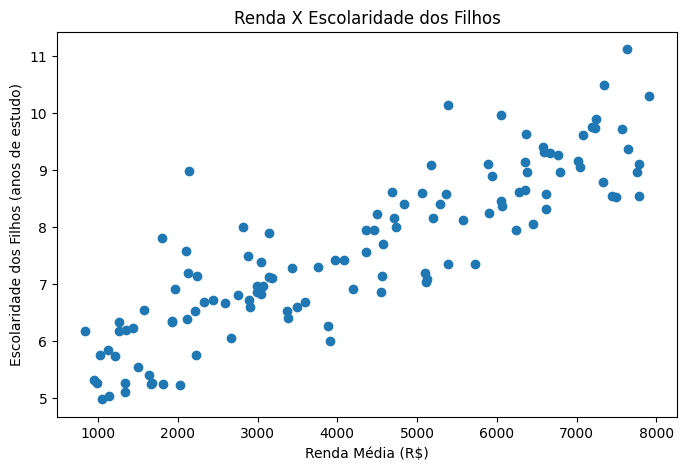


=== RESULTADOS ===
Intercepto (a): 5.1412
Coeficiente angular (b): 0.000577
R²: 0.7639

Equação estimada:
y = 5.14 + (0.000577 * x)

=== INTERPRETAÇÃO ===
Existe uma relação POSITIVA entre renda e escolaridade dos filhos.
O modelo explica aproximadamente 76.39% da variação da escolaridade.


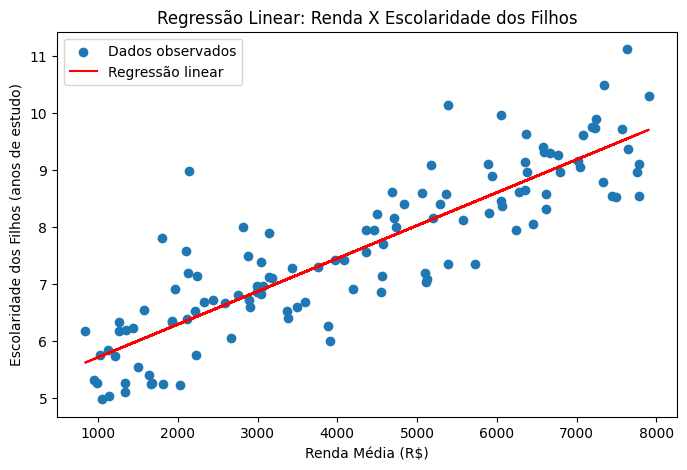


Conclusão:
Os dados simulados indicam que quanto maior a renda média, maior o tempo de permanência dos filhos na escola, demonstrando uma relação linear positiva entre as variáveis.


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# Garante reprodutibilidade dos dados aleatórios

np.random.seed(42)


# Criação dos dados

n = 120

# Variável independente (X): renda média
renda_media = np.random.uniform(800, 8000, n)

# Criação da relação linear
# quanto maior a renda, maior a escolaridade dos filhos

escolaridade_filhos = 5 + (0.0006 * renda_media)

# Adicionando ruído para simular realidade
ruido = np.random.normal(0, 0.7, n)

escolaridade_filhos = escolaridade_filhos + ruido

# Garantindo valores mínimos coerentes (ex: não negativos)
escolaridade_filhos = np.clip(escolaridade_filhos, 0, None)


#Grafico

df = pd.DataFrame({
    'renda_media': renda_media,
    'escolaridade_filhos': escolaridade_filhos
})

# Exibindo os primeiros registros simulados
print("Primeiras linhas da tabela:")
print(df.head())

# Exibindo a estatítica dos dados

print("\nEstatística descritiva:")
print(df.describe())


#Gráfico de Dispersão

plt.figure(figsize=(8,5))

plt.scatter(
    df['renda_media'],
    df['escolaridade_filhos']
)

plt.xlabel("Renda Média (R$)")
plt.ylabel("Escolaridade dos Filhos (anos de estudo)")
plt.title("Renda X Escolaridade dos Filhos")

plt.show()


#Regressão Linear

X_renda2 = df[['renda_media']]
y_escolaridade = df['escolaridade_filhos']

modelo = LinearRegression()
modelo.fit(X_renda2, y_escolaridade)

y_escolaridade_pred = modelo.predict(X_renda2)


#Resultados

print("\n=== RESULTADOS ===")

print(f"Intercepto (a): {modelo.intercept_:.4f}")
print(f"Coeficiente angular (b): {modelo.coef_[0]:.6f}")

r2 = r2_score(y, y_pred)
print(f"R²: {r2:.4f}")

print("\nEquação estimada:")
print(f"y = {modelo.intercept_:.2f} + ({modelo.coef_[0]:.6f} * x)")


#Interpretação

print("\n=== INTERPRETAÇÃO ===")

if modelo.coef_[0] > 0:
    print("Existe uma relação POSITIVA entre renda e escolaridade dos filhos.")
else:
    print("Existe uma relação NEGATIVA entre renda e escolaridade dos filhos.")

print(f"O modelo explica aproximadamente {r2*100:.2f}% da variação da escolaridade.")


#Grafico Regressão

plt.figure(figsize=(8,5))

plt.scatter(
    df['renda_media'],
    df['escolaridade_filhos'],
    label='Dados observados'
)

plt.plot(
    df['renda_media'],
    y_pred,
    color='red',
    label='Regressão linear'
)

plt.xlabel("Renda Média (R$)")
plt.ylabel("Escolaridade dos Filhos (anos de estudo)")
plt.title("Regressão Linear: Renda X Escolaridade dos Filhos")
plt.legend()

plt.show()

# CONCLUSÃO


print("\nConclusão:")

print(
    "Os dados simulados indicam que quanto maior a renda média, "
    "maior o tempo de permanência dos filhos na escola, "
    "demonstrando uma relação linear positiva entre as variáveis."
)

## **2. Correlação**

Vamos partir do **conceito central** da estatística sobre a correlação:

### "A correlação é um método estatístico que **mede o grau de associação** entre **duas variáveis**, ou seja, como elas variam juntas"

Ou seja, é um método para compreender o comportamento do conjunto de dados e responder as seguintes perguntas:

*  Quando uma variável aumenta, a outra também aumenta?
*  Quando uma aumenta, a outra diminui?
*  Existe alguma relação entre elas?
*  Essa relação é forte ou fraca?

**Tipos de correlação:**

*  Positiva - Quando uma variável aumenta, a outra também aumenta
*  Negativa - Quando uma variável aumenta a outra diminui
*  Nula - Não existe relação aparente entre as variáveis

Para essa aula, duas correlações serão exemplificadas, que são as mais comuns:

*  **Correlação de Pearson:**

Calcula o grau de correlação (a intensidade da direção) da relação linear entre duas variáveis numéricas. Essas variáveis **variam de -1 a 1** e quanto mais próximo de 0, é possivel afirmar que as variáveis não possuem relação linear (**nula**), contudo, quando o valor estimado for mais proximo de -1, podemos afirmar que as variáveis apresentam correlação linear **negativa**  e quanto mais proximo de 1, uma relação linear **positiva**.

Em resumo:

**r = representa o coeficiente de correlação**
1.   r= 1	correlação positiva perfeita
2.   r> 0	correlação positiva
3.   r= 0	ausência de correlação linear
4.   r< 0	correlação negativa
5.   r= -1	correlação negativa perfeita



*  **Correlação de Spearman**

Calcula o grau de correlação entre duas variáveis, mas não necessariamente linear. Nessa correlação, é utilizado rankings para efetuar os calculos de correlação. Assim como a correlação de Pearson, a de Spearman também vária de -1 a 1, seguindo a mesma lógica.

*  **Correlação de Tau de Kendall**

Calcula o grau de correlação entre duas variáveis, mas não necessariamente linear. Nessa correlação, é utilizado rankings para efetuar os calculos de correlação. Diferente da correlação de Spearman, a **Correlação de Tau de Kendall** observa e avalia a associação de duas variáveis com base na concordância e discondância entre **pares** de observações. O resultado também vária de -1 a 1, seguindo a mesma lógica das outras.

### **Exemplo:**

Vamos analisar as correlações das variáveis utilizadas nos exemplos anteriores, que foi a renda x déficit habitacil e a renda x escolaridade dos filhos (anos de estudo).

In [ ]:


# Correlação de Pearson para renda x déficit habitacional

print("Correlação entre as variáveis de renda e déficit habitacional")


from scipy.stats import pearsonr

coef_pearson, p_pearson = pearsonr(
    X_renda.squeeze(),
    y_deficithab
)

print("\n📊 Correlação de Pearson")

print(f"Coeficiente: {coef_pearson:.4f}")
print(f"P-valor: {p_pearson:.4e}")


# Significância estatística
if p_pearson < 0.05:
    print("✔ Resultado estatisticamente significativo (α = 0.05).")
else:
    print("✖ Resultado não significativo (α = 0.05).")


# Direção da correlação
if coef_pearson > 0:
    print("➡ Existe correlação linear positiva.")
elif coef_pearson < 0:
    print("➡ Existe correlação linear negativa.")
else:
    print("➡ Não existe correlação linear.")


# Intensidade da correlação
if abs(coef_pearson) >= 0.70:
    print("➡ Correlação forte.")
elif abs(coef_pearson) >= 0.40:
    print("➡ Correlação moderada.")
else:
    print("➡ Correlação fraca.")


# Correlação de Spearman para renda x déficit habitacional

from scipy.stats import spearmanr

coef_spearman, p_spearman = spearmanr(
    X_renda.squeeze(),
    y_deficithab
)

print("\n📊 Correlação de Spearman")

print(f"Coeficiente: {coef_spearman:.4f}")
print(f"P-valor: {p_spearman:.4e}")


# Significância estatística
if p_spearman < 0.05:
    print("✔ Resultado estatisticamente significativo (α = 0.05).")
else:
    print("✖ Resultado não significativo (α = 0.05).")


# Direção da correlação
if coef_spearman > 0:
    print("➡ Existe correlação monotônica positiva.")
elif coef_spearman < 0:
    print("➡ Existe correlação monotônica negativa.")
else:
    print("➡ Não existe correlação monotônica.")


# Intensidade da correlação
if abs(coef_spearman) >= 0.70:
    print("➡ Correlação forte.")
elif abs(coef_spearman) >= 0.40:
    print("➡ Correlação moderada.")
else:
    print("➡ Correlação fraca.")

    # Correlação Tau de Kendall para renda x déficit habitacional

from scipy.stats import kendalltau

coef_kendall, p_kendall = kendalltau(
    X_renda.squeeze(),
    y_deficithab
)

print("\n📊 Correlação Tau de Kendall")

print(f"Coeficiente: {coef_kendall:.4f}")
print(f"P-valor: {p_kendall:.4e}")


# Significância estatística
if p_kendall < 0.05:
    print("✔ Resultado estatisticamente significativo (α = 0.05).")
else:
    print("✖ Resultado não significativo (α = 0.05).")


# Direção da correlação
if coef_kendall > 0:
    print("➡ Existe concordância positiva entre as variáveis.")
elif coef_kendall < 0:
    print("➡ Existe concordância negativa entre as variáveis.")
else:
    print("➡ Não existe concordância entre as variáveis.")


# Intensidade da correlação
if abs(coef_kendall) >= 0.70:
    print("➡ Correlação forte.")
elif abs(coef_kendall) >= 0.40:
    print("➡ Correlação moderada.")
else:
    print("➡ Correlação fraca.")
#-----------------------------------------------------


Correlação entre as variáveis de renda e déficit habitacional

📊 Correlação de Pearson
Coeficiente: -0.9387
P-valor: 4.1221e-47
✔ Resultado estatisticamente significativo (α = 0.05).
➡ Existe correlação linear negativa.
➡ Correlação forte.

📊 Correlação de Spearman
Coeficiente: -0.9400
P-valor: 1.4493e-47
✔ Resultado estatisticamente significativo (α = 0.05).
➡ Existe correlação monotônica negativa.
➡ Correlação forte.

📊 Correlação Tau de Kendall
Coeficiente: -0.7859
P-valor: 4.9169e-31
✔ Resultado estatisticamente significativo (α = 0.05).
➡ Existe concordância negativa entre as variáveis.
➡ Correlação forte.


In [ ]:
# Correlação de Pearson para renda x escolaridade dos filhos (anos de estudo)

print("Correlação entre as variáveis de renda e escolaridade dos filhos (anos de estudo)")

from scipy.stats import pearsonr

coef_pearson, p_pearson = pearsonr(
    X_renda2.squeeze(),
    y_escolaridade
    )

print("\n📊 Correlação de Pearson")

print(f"Coeficiente: {coef_pearson:.4f}")
print(f"P-valor: {p_pearson:.4e}")


# Significância estatística
if p_pearson < 0.05:
    print("✔ Resultado estatisticamente significativo (α = 0.05).")
else:
    print("✖ Resultado não significativo (α = 0.05).")


# Direção da correlação
if coef_pearson > 0:
    print("➡ Existe correlação linear positiva.")
elif coef_pearson < 0:
    print("➡ Existe correlação linear negativa.")
else:
    print("➡ Não existe correlação linear.")


# Intensidade da correlação
if abs(coef_pearson) >= 0.70:
    print("➡ Correlação forte.")
elif abs(coef_pearson) >= 0.40:
    print("➡ Correlação moderada.")
else:
    print("➡ Correlação fraca.")
# Correlação de Spearman para renda x escolaridade dos filhos (anos de estudo)

from scipy.stats import spearmanr

coef_spearman, p_spearman = spearmanr(
    X_renda2.squeeze(),
    y_escolaridade
)

print("\n📊 Correlação de Spearman")

print(f"Coeficiente: {coef_spearman:.4f}")
print(f"P-valor: {p_spearman:.4e}")


# Significância estatística
if p_spearman < 0.05:
    print("✔ Resultado estatisticamente significativo (α = 0.05).")
else:
    print("✖ Resultado não significativo (α = 0.05).")


# Direção da correlação
if coef_spearman > 0:
    print("➡ Existe correlação monotônica positiva.")
elif coef_spearman < 0:
    print("➡ Existe correlação monotônica negativa.")
else:
    print("➡ Não existe correlação monotônica.")


# Intensidade da correlação
if abs(coef_spearman) >= 0.70:
    print("➡ Correlação forte.")
elif abs(coef_spearman) >= 0.40:
    print("➡ Correlação moderada.")
else:
    print("➡ Correlação fraca.")

    # Correlação Tau de Kendall para renda x escolaridade dos filhos (anos de estudo)

from scipy.stats import kendalltau

coef_kendall, p_kendall = kendalltau(
    X_renda2.squeeze(),
    y_escolaridade
)

print("\n📊 Correlação Tau de Kendall")

print(f"Coeficiente: {coef_kendall:.4f}")
print(f"P-valor: {p_kendall:.4e}")


# Significância estatística
if p_kendall < 0.05:
    print("✔ Resultado estatisticamente significativo (α = 0.05).")
else:
    print("✖ Resultado não significativo (α = 0.05).")


# Direção da correlação
if coef_kendall > 0:
    print("➡ Existe concordância positiva entre as variáveis.")
elif coef_kendall < 0:
    print("➡ Existe concordância negativa entre as variáveis.")
else:
    print("➡ Não existe concordância entre as variáveis.")


# Intensidade da correlação
if abs(coef_kendall) >= 0.70:
    print("➡ Correlação forte.")
elif abs(coef_kendall) >= 0.40:
    print("➡ Correlação moderada.")
else:
    print("➡ Correlação fraca.")

Correlação entre as variáveis de renda e escolaridade dos filhos (anos de estudo)

📊 Correlação de Pearson
Coeficiente: 0.8740
P-valor: 8.5288e-39
✔ Resultado estatisticamente significativo (α = 0.05).
➡ Existe correlação linear positiva.
➡ Correlação forte.

📊 Correlação de Spearman
Coeficiente: 0.8803
P-valor: 5.1251e-40
✔ Resultado estatisticamente significativo (α = 0.05).
➡ Existe correlação monotônica positiva.
➡ Correlação forte.

📊 Correlação Tau de Kendall
Coeficiente: 0.6952
P-valor: 2.0783e-29
✔ Resultado estatisticamente significativo (α = 0.05).
➡ Existe concordância positiva entre as variáveis.
➡ Correlação moderada.


## **Quando usar Pearson, Spearman e Tau de Kendall**

**Pearson:**


*   Os dados forem contínuos;
*   A relação parecer uma reta;
*   Não houver muitos outliers (pontos distantes dos demais dados/fora da curva);
*   Os dados forem aproximadamente normais.

**Spearman:**

*   A relação não for linear, mas ainda seguir tendência crescente/decrescente;
*   Existirem outliers;
*   Os dados forem ordinais ou não normais.

**Tau de Kendall:**

*   A amostra for pequena;
*   Existirem muitos valores repetidos (empates);
*   Médida mais robusta e conservadora.

**Fontes e leituras complementares:**
*  [Estatística aplicada à pesquisa - Estimação de Parâmetros - Profa. Sonia Muller (UFPR)](https://docs.ufpr.br/~soniaisoldi/TP707/Aula5.pdf)
* [Estimação Estatística - Editora Pantanal](https://www.editorapantanal.com.br/ebooks/2021/estimacao-estatistica/ebook.pdf)
* [Data Science - Um guia teórico de ciência de dados e machine larning - Luiza Reixach Castro](https://drive.google.com/file/d/1fwK9qhWDiTkfIHdw8TGrjlyIonSv1CUX/view?usp=sharing)

* [Introdução aos modelos de regressão linear - ENAP](https://bibliotecadigital.enap.gov.br/bitstream/1/4788/1/Livro_Regress%C3%A3o%20Linear.pdf)